# Import Packages (Enhanced model)

In [1]:
import sys
print(sys.executable)

c:\Users\xin37\github\CNN-LSTM-model-for-energy-usage-forecasting-1\venv\Scripts\python.exe


In [4]:
# univariate multi-step lstm for the power usage dataset

import time

# Start counting notebook running time
time_start = time.time()

import numpy as np
import tensorflow as tf
# Set all random seeds for the program (Python, NumPy, and TensorFlow)
tf.keras.utils.set_random_seed(1)

import pandas as pd
from  IPython.display import display, Image
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM, RepeatVector, TimeDistributed, Dropout
from keras.layers import Conv1D, MaxPooling1D
from keras import regularizers
from keras.utils import plot_model
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
import sklearn
import keras
import pandas as pd
from sklearn.preprocessing import StandardScaler
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from time import strftime
current_time = strftime("%Y-%m-%d-%H-%M-%S")
print('current time: ', current_time)
print('numpy version: ', np.__version__)
print('tensorflow version: ', tf.__version__)
print('pandas version: ', pd.__version__)
print('scikit-learn version: ', sklearn.__version__)
print('keras version: ', keras.__version__)

current time:  2026-04-17-01-57-55
numpy version:  2.4.4
tensorflow version:  2.21.0
pandas version:  3.0.2
scikit-learn version:  1.8.0
keras version:  3.14.0


# latest 1.0

In [75]:
import pandas as pd

# 1. Load the dataset and parse the timestamps
# Update 'hvac_data.csv' to whatever the extracted file is named
file_path = 'C:\\Users\\xin37\\github\\CNN-LSTM-model-for-energy-usage-forecasting-1\\data\\HVAC_NE_EC_19-21.csv' 

print("Loading and parsing dataset...")
# parse_dates=['Timestamp'] converts the string into a datetime object
# index_col='Timestamp' makes the time the index, which is essential for time-series
df = pd.read_csv(file_path, parse_dates=['Timestamp'], index_col='Timestamp')

# Note: The timestamps have timezone offsets (+02:00). 
# If this causes issues with your scaler or model later, uncomment the line below 
# to convert everything to a clean, timezone-naive format:
df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)

# Quick check to ensure data loaded correctly
print("Data loaded successfully! Shape:", df.shape)
print("\n--- First 3 Rows ---")
print(df.head(3))
print("\n")

# 2. Define the target variable we want to predict
TARGET = 'T_Return'

# 3. STANDARD CORRELATION
print("==========================================================")
print("1. STANDARD CORRELATION (Relationships at the exact SAME time)")
print("==========================================================")
# Shows how variables move together in the exact same 15-minute window
standard_corr = df.corr()[TARGET].sort_values(ascending=False)
print(standard_corr)
print("\n")

# 4. LAGGED CORRELATION (The most important metric for forecasting)
print("==========================================================")
print("2. LAGGED CORRELATION (Predicting 15 mins into the FUTURE)")
print("==========================================================")

# Create a copy so we don't mess up the original dataframe
df_lagged = df.copy()

# Shift the target variable UP by 1 row (-1). 
# If row 0 is 00:00, its 'Target_Next_15_Mins' will now be the T_Return from 00:15.
df_lagged['Target_Next_15_Mins'] = df_lagged[TARGET].shift(-1)

# Calculate correlation against the new shifted target.
# We drop the current 'T_Return' from the output list just to see how the 
# OTHER variables (Power, Outdoor Temp, etc.) predict the future temperature.
lagged_corr = df_lagged.corr()['Target_Next_15_Mins'].drop(TARGET, errors='ignore').sort_values(ascending=False)
df_lagged = df_lagged.dropna()
print(lagged_corr)

Loading and parsing dataset...
Data loaded successfully! Shape: (33888, 10)

--- First 3 Rows ---
                      T_Supply   T_Return  SP_Return  T_Saturation  T_Outdoor  \
Timestamp                                                                       
2019-10-14 22:00:00  19.859999  20.469999       18.5         19.02  20.299999   
2019-10-14 22:15:00  19.855000  20.430000       18.5         19.02  20.299999   
2019-10-14 22:30:00  19.850000  20.410000       18.5         19.02  20.299999   

                     RH_Supply  RH_Return  RH_Outdoor  Energy  Power  
Timestamp                                                             
2019-10-14 22:00:00  71.110001  58.919998        79.5     0.0    0.0  
2019-10-14 22:15:00  71.320000  59.000000        82.0     0.0    0.0  
2019-10-14 22:30:00  71.470001  59.109997        79.5     0.0    0.0  


1. STANDARD CORRELATION (Relationships at the exact SAME time)
T_Return        1.000000
T_Supply        0.825405
T_Saturation    0.654465
T

In [76]:
def detect_outliers_iqr(df, cols):
    outlier_flags = pd.DataFrame(index=df.index)
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outlier_flags[col + '_outlier'] = ((df[col] < lower) | (df[col] > upper))
    
    return outlier_flags

num_cols = df.select_dtypes(include=["float64", "int64"]).columns
outliers = detect_outliers_iqr(df, num_cols)

print(f"\nOutlier summary (IQR method):\n",outliers.sum())


Outlier summary (IQR method):
 T_Supply_outlier           0
T_Return_outlier         257
SP_Return_outlier       6183
T_Saturation_outlier     347
T_Outdoor_outlier        689
RH_Supply_outlier        914
RH_Return_outlier        877
RH_Outdoor_outlier         0
Energy_outlier             0
Power_outlier              0
dtype: int64


# latest 1.1

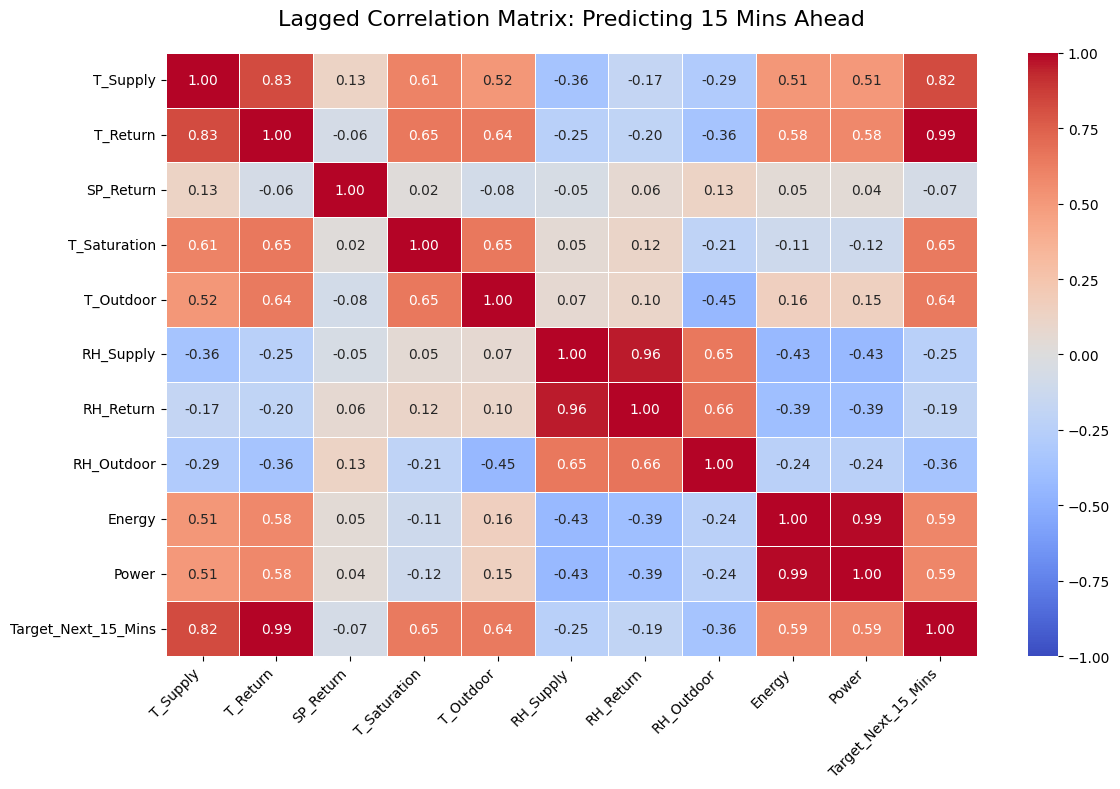

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the lagged target
df_lagged = df.copy()
df_lagged['Target_Next_15_Mins'] = df_lagged['T_Return'].shift(-1)

# 2. Calculate the correlation matrix
corr_matrix = df_lagged.corr()

# 3. Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,              
    cmap='coolwarm',         
    fmt=".2f",               
    linewidths=0.5,          
    vmin=-1, vmax=1          
)

plt.title('Lagged Correlation Matrix: Predicting 15 Mins Ahead', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize sample data

# latest 1.2

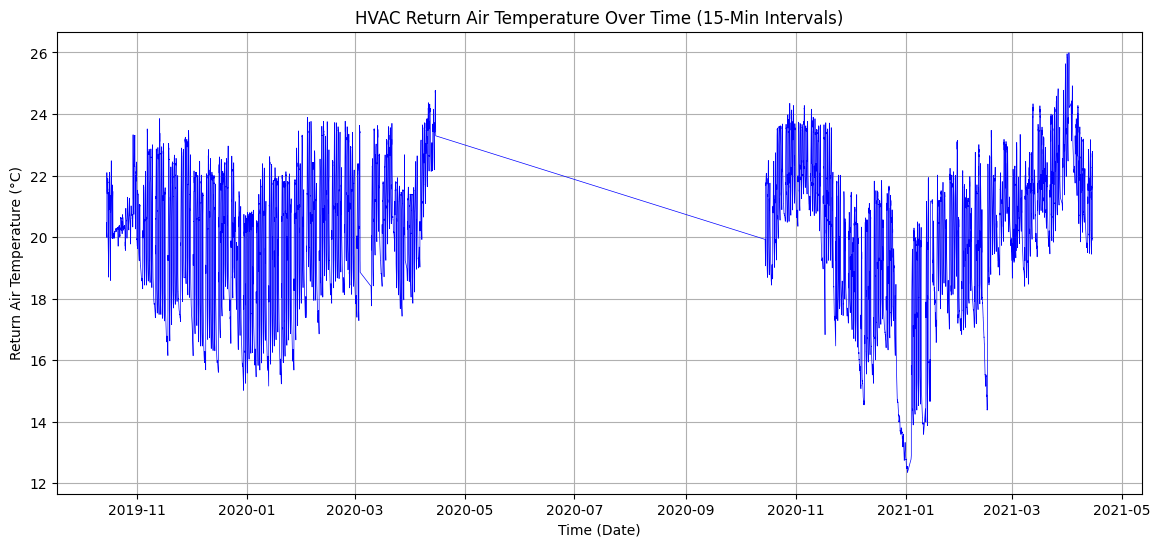

CPU times: total: 141 ms
Wall time: 144 ms


In [78]:
%%time
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 6)) # Made slightly wider for 33,000+ rows

# Using the new target variable from the Kaggle dataset
plt.plot(df.index, df['T_Return'], color='blue', linewidth=0.5) 

plt.xlabel('Time (Date)')
plt.ylabel('Return Air Temperature (°C)')
plt.title('HVAC Return Air Temperature Over Time (15-Min Intervals)')
plt.grid(True) 
plt.show()

# Split a dataset into train/test sets

# latest 1.3

In [83]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# UPDATED PARAMETERS FOR 15-MINUTE DATA
# ==========================================
df_lagged = df_lagged.dropna()
n_input  = 8         # Look back 2 hours (8 steps * 15 mins = 120 mins)
n_output = 1         # Predict next 15 mins (1 step)

# Math for 1 week: 4 steps per hour * 24 hours * 7 days = 672 steps
test_size = 4 * 24 * 7  

# Using the highly correlated features we discovered
FEATURE_COLS = [
    'T_Return',
    'T_Supply',
    'T_Outdoor',
    'Power',
    'RH_Outdoor',
    'SP_Return',
    'Power'
]

# TARGET_COL = 'T_Return'
TARGET_COL = 'Target_Next_15_Mins'

# 3. Create Sliding Windows
def create_sequences(X, y, n_input, n_output):
    X_seq, y_seq = [], []
    for i in range(len(X) - n_input - n_output + 1):
        X_seq.append(X[i : i + n_input])
        y_seq.append(y[i + n_input : i + n_input + n_output])
    return np.array(X_seq), np.array(y_seq).squeeze()

# 4. Split and Scale Function
def prepare_data(data, test_size_steps):
    split_idx = len(data) - test_size_steps
    
    # Split into Train and Test sets
    train_df = data.iloc[:split_idx] 
    test_df = data.iloc[split_idx:] 
    
    # Scale Features
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(train_df[FEATURE_COLS]) 
    X_test_scaled = scaler.transform(test_df[FEATURE_COLS]) 
    
    target_scaler = MinMaxScaler()
    y_train_scaled = target_scaler.fit_transform(train_df[[TARGET_COL]])
    y_test_scaled  = target_scaler.transform(test_df[[TARGET_COL]])
    
    # Create Sequences
    X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, n_input, n_output)
    X_test, y_test = create_sequences(X_test_scaled, y_test_scaled, n_input, n_output)
    
    return X_train, y_train, X_test, y_test, scaler, target_scaler, X_train_scaled, X_test_scaled

# Execute
# X_train, y_train, X_test, y_test, scaler, target_scaler, X_train_scaled, X_test_scaled = prepare_data(df, test_size)
X_train, y_train, X_test, y_test, scaler, target_scaler, X_train_scaled, X_test_scaled = prepare_data(df_lagged, test_size)

# Verify Shapes
print(f"X_train shape: {X_train.shape}") # Should be (Samples, 8, 4)
print(f"y_train shape: {y_train.shape}") # Should be (Samples,)

X_train shape: (33207, 8, 7)
y_train shape: (33207,)


# Define function for building model
In this model architecture, a one-dimensional convolutional neural network (1D CNN) is used to read and encode the input sequence. An LSTM network is then used as a decoder to make ode-step prediction for each value in the output sequence.

In [84]:
# build and train the model
def build_model(X_train_data, y_train_data, X_val_data, y_val_data):

    n_input = X_train_data.shape[1]
    n_features = X_train_data.shape[2]

    # define model
    model = Sequential([
        #-------CNN-------
        Conv1D(64, 5, activation='relu', padding='same', input_shape=(n_input, n_features)),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        #-------CNN-------
        #-------LSTM-------
        LSTM(64, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        Dense(1)
        #-------LSTM-------
    ])


    model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005))
    model.summary()
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

    # fit network and save the history
    training_history = model.fit(
        X_train_data, y_train_data, 
        epochs=150, batch_size= 32, 
        verbose= 1, 
        validation_data=(X_val_data, y_val_data), 
        callbacks = [early_stop, reduce_lr])

    return model, training_history

# Define function for evaluating model

# Train model and make predictions

# latest 1.4

X_train shape: (33207, 8, 7)
y_train shape: (33207,)


c:\Users\xin37\github\CNN-LSTM-model-for-energy-usage-forecasting-1\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 64)          │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,441 (146.25 KB)

 Trainable params: 37,441 (146.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
831/831 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1121 - val_loss: 0.0064 - learning_rate: 5.0000e-04
Epoch 2/150
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0040 - val_loss: 0.0017 - learning_rate: 5.0000e-04
Epoch 3/150
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0025 - val_loss: 0.0015 - learning_rate: 5.0000e-04
Epoch 4/150
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0022 - val_loss: 0.0014 - learning_rate: 5.0000e-04
Epoch 5/150
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0020 - val_loss: 0.0017 - learning_rate: 5.0000e-04
Epoch 6/150
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0019 - val_loss: 0.0012 - learning_rate: 5.0000e-04
Epoch 7/150
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0018 - val_loss: 0.0013 - learning_rate: 5.0000e-04
Epoch 8/150
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0017 - val_loss: 0.0013 - learning_rate: 5.0000e-04
Epoch 9/150
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0017 - val_loss: 

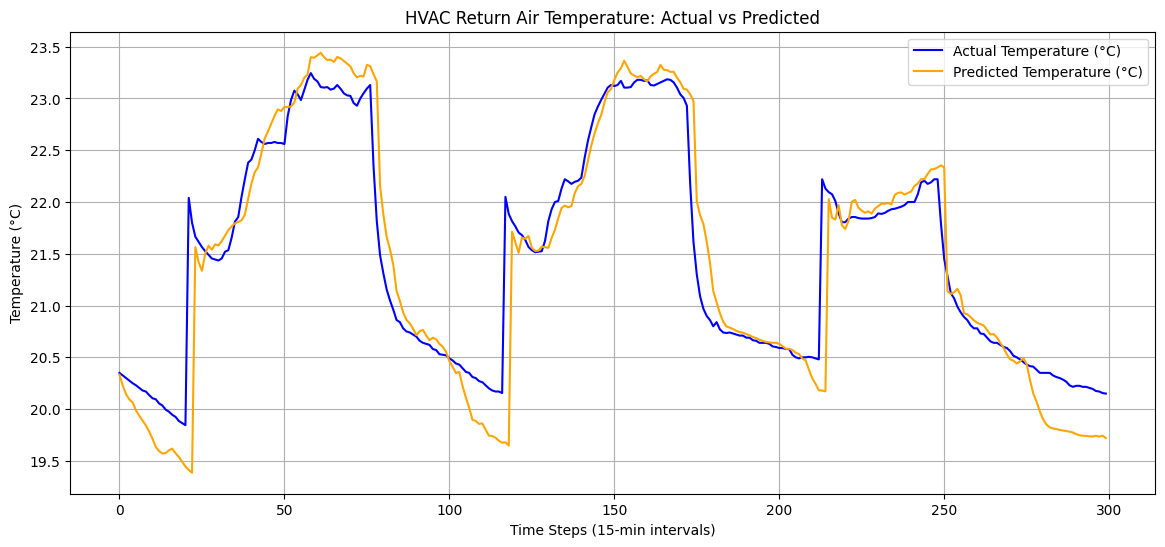

CPU times: total: 5min 37s
Wall time: 2min 30s


In [85]:
%%time
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & TRAINING
# ==========================================
# Clear old model from memory
tf.keras.backend.clear_session()

# Prepare data (Assuming prepare_data is already defined above)
# X_train, y_train, X_test, y_test, scaler, target_scaler, X_train_scaled, X_test_scaled = prepare_data(df, test_size)
X_train, y_train, X_test, y_test, scaler, target_scaler, X_train_scaled, X_test_scaled = prepare_data(df_lagged, test_size)


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# Split validation (last 20% of training data)
val_size = int(len(X_train) * 0.2)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

# Train model (Using the updated batch_size=32 inside this function)
model, training_history = build_model(X_tr, y_tr, X_val, y_val)

# ==========================================
# 2. EVALUATION & PREDICTION
# ==========================================
print("\nGenerating predictions...")
# Predict the whole test set in one go using the sequenced X_test
y_pred_scaled = model.predict(X_test)

# Inverse Transform to get real Degrees Celsius back
predictions_celsius = target_scaler.inverse_transform(y_pred_scaled)
actual_celsius = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# ==========================================
# 3. METRICS & PLOTTING
# ==========================================
rmse = np.sqrt(mean_squared_error(actual_celsius, predictions_celsius))
mae = mean_absolute_error(actual_celsius, predictions_celsius)
r2 = r2_score(actual_celsius, predictions_celsius)

print("\n--- FINAL RESULTS ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} °C")
print(f"Mean Absolute Error (MAE): {mae:.4f} °C")
print(f"R-squared Score (R2): {r2:.4f}")

# Plot the Results (First 300 steps for clarity)
plt.figure(figsize=(14, 6))
plt.plot(actual_celsius[:300], label='Actual Temperature (°C)', color='blue', linewidth=1.5)
plt.plot(predictions_celsius[:300], label='Predicted Temperature (°C)', color='orange', linewidth=1.5)
plt.title('HVAC Return Air Temperature: Actual vs Predicted')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

# Visualize model architecture

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


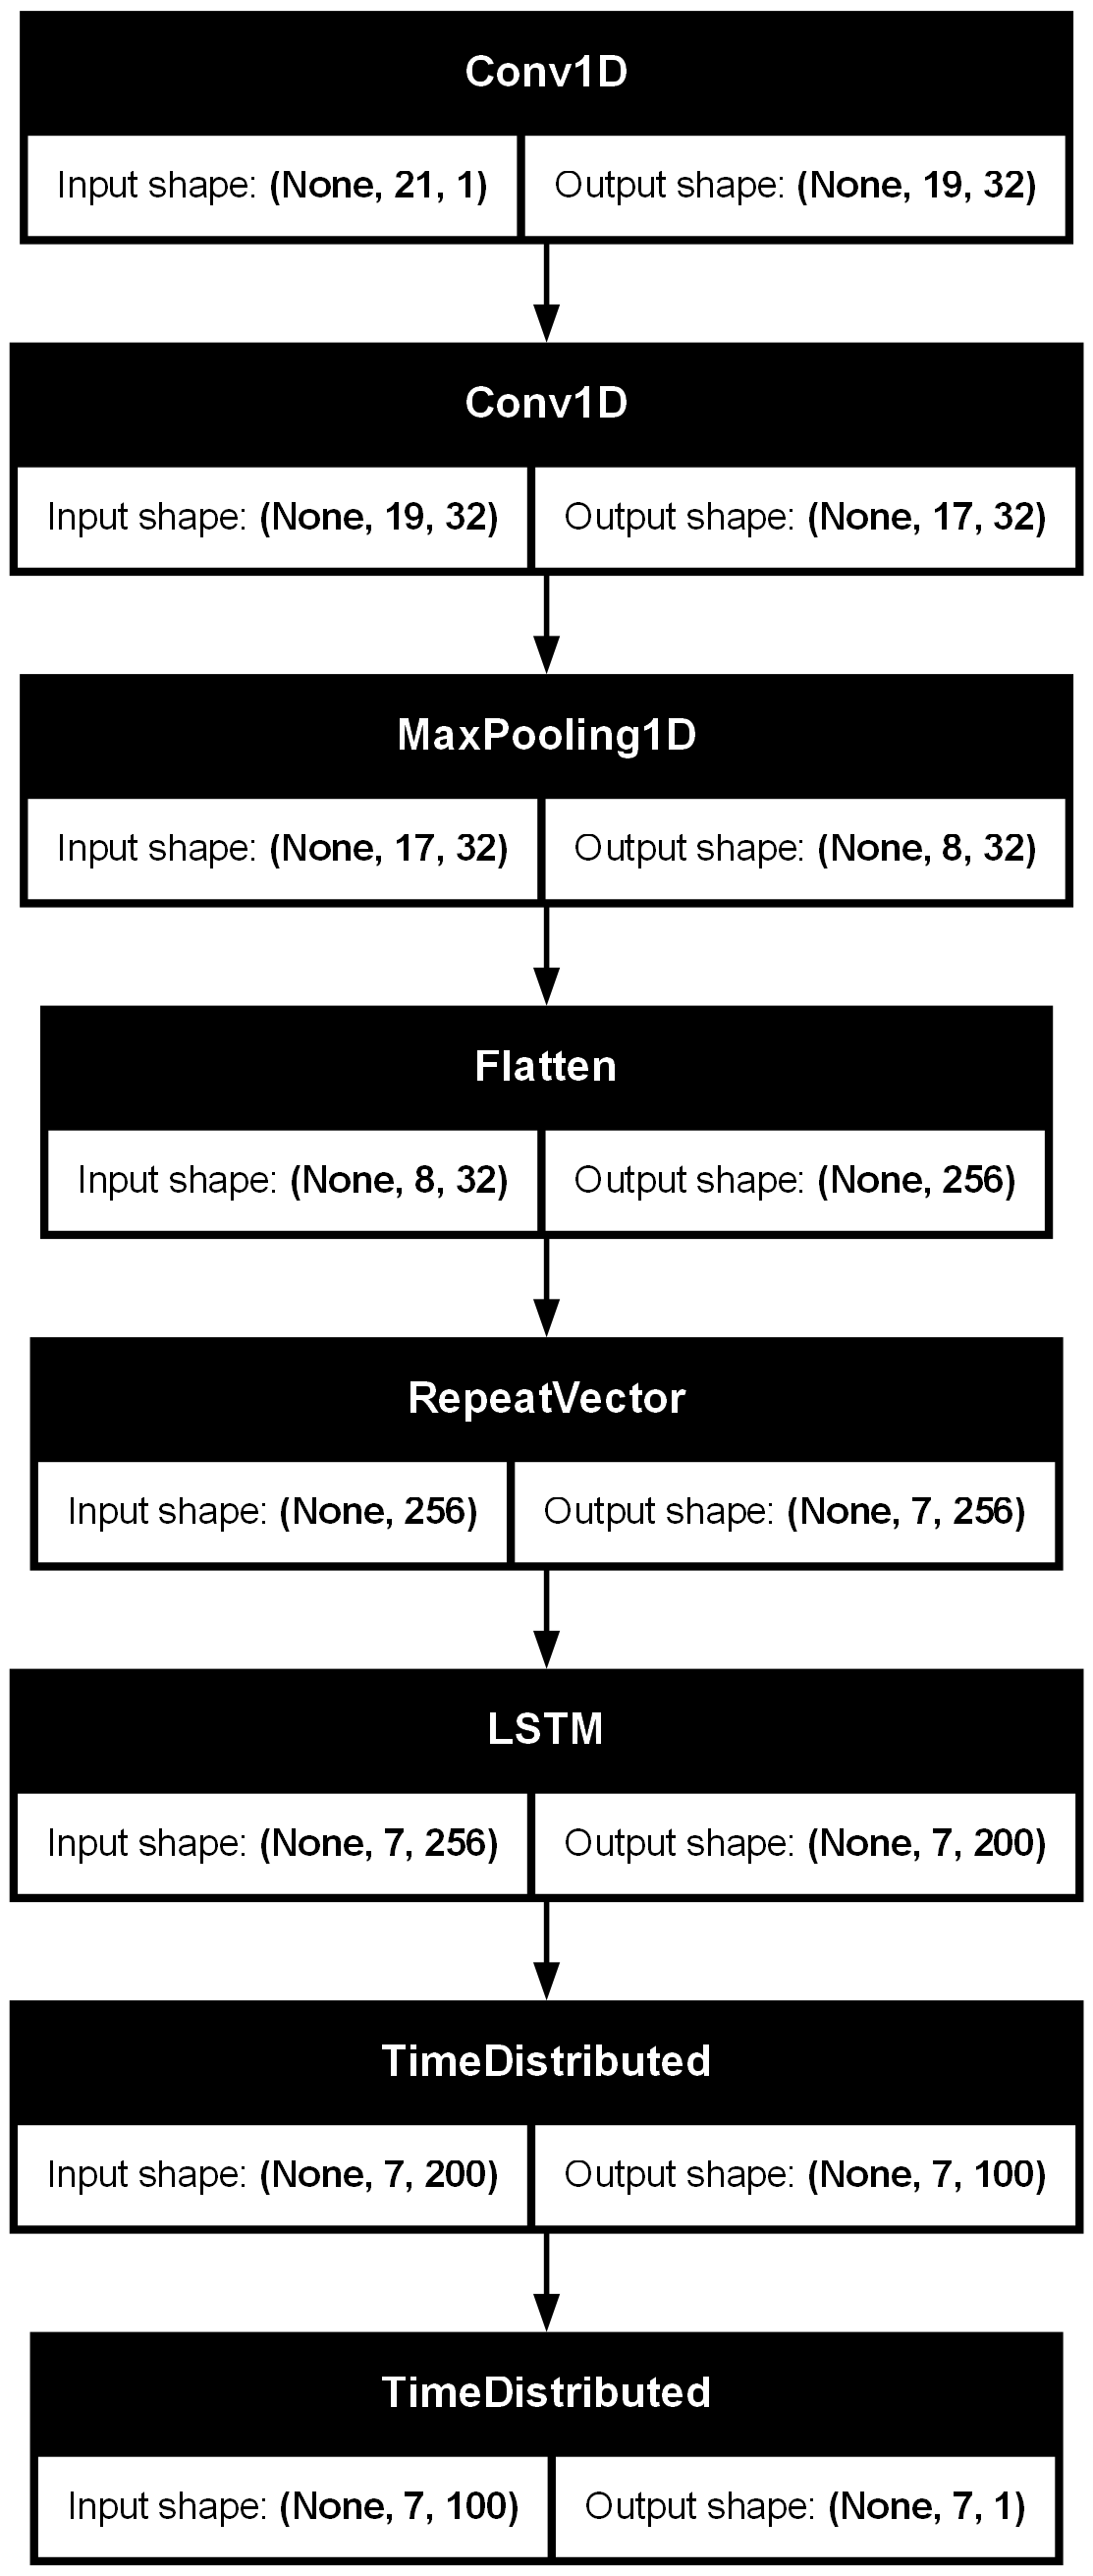

In [21]:
from IPython.display import Image, display
from tensorflow.keras.utils import plot_model

# model is already built, no need to call build_model again
# just plot and display directly

plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
display(Image(filename='model_architecture.png'))

# Compare actual and predicted values

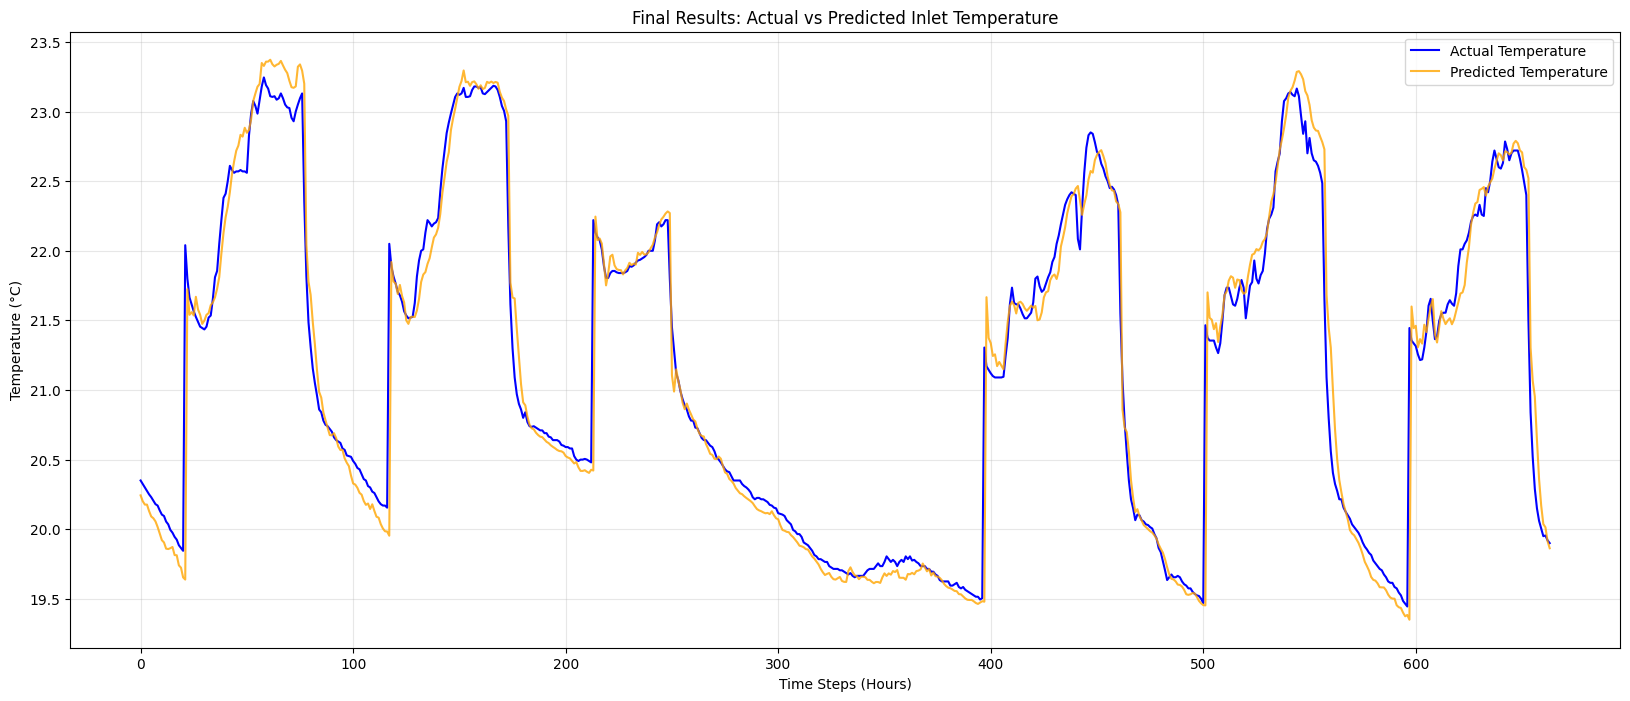

MAE: 0.1289 °C
RMSE: 0.2557 °C


In [24]:
min_len = min(len(actual_celsius), len(predictions_celsius))
final_actual = actual_celsius[:min_len]
final_pred = predictions_celsius[:min_len]

def plot_results(actual, predicted):
    plt.figure(figsize=(20, 8))
    plt.plot(actual, label='Actual Temperature', color='blue', linewidth=1.5)
    plt.plot(predicted, label='Predicted Temperature', color='orange', alpha=0.8, linewidth=1.5)
    plt.title('Final Results: Actual vs Predicted Inlet Temperature')
    plt.ylabel('Temperature (°C)')
    plt.xlabel('Time Steps (Hours)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the plot with the Celsius variables
plot_results(final_actual, final_pred)

# --- 4. Accuracy Check ---
from sklearn.metrics import mean_absolute_error, mean_squared_error
print(f"MAE: {mean_absolute_error(final_actual, final_pred):.4f} °C")
print(f"RMSE: {np.sqrt(mean_squared_error(final_actual, final_pred)):.4f} °C")

# RMSE for all sequences

In [218]:
time_end = time.time()
print("Notebook run time: {:.0f} seconds".format(time_end - time_start))

Notebook run time: 4613 seconds


## Performance metric for the baseline model (CNN-LSTM) and Models training loss and validation loss

Root Mean Squared Error (RMSE): 0.2557 °C
Mean Absolute Error (MAE): 0.1289 °C
R-squared Score (R2): 0.9515


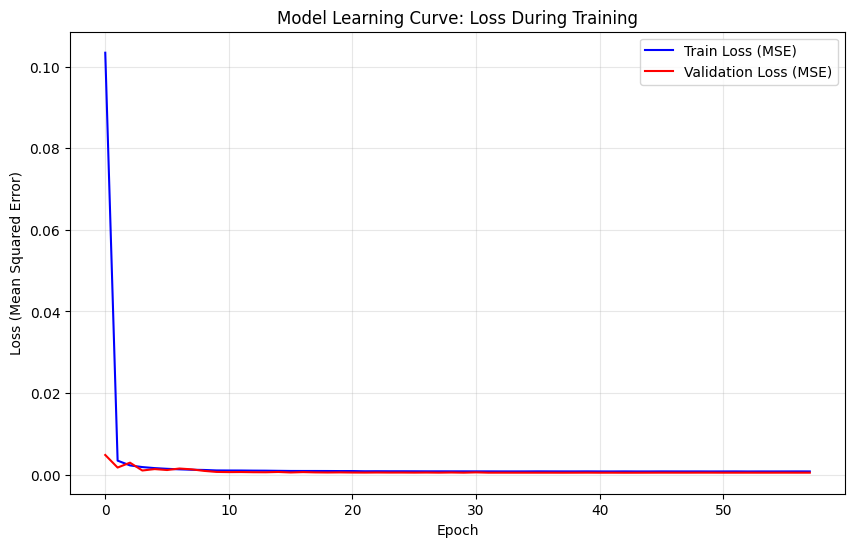

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

def return_performance_metrics(actual_vals, predicted_vals):
    rmse = np.sqrt(mean_squared_error(actual_vals, predicted_vals))
    mae = mean_absolute_error(actual_vals, predicted_vals)
    r2 = r2_score(actual_vals, predicted_vals)
    
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f} °C")
    print(f"Mean Absolute Error (MAE): {mae:.4f} °C")
    print(f"R-squared Score (R2): {r2:.4f}")
    # print("Actual Values:", actual_vals)
    # print("Predicted Values:", predicted_vals)
    return rmse, mae, r2

# Use the variables we aligned in the previous cell
# final_actual and final_pred are the Celsius versions
metrics = return_performance_metrics(final_actual, final_pred)

# --- Training Loss Plot ---
plt.figure(figsize=(10, 6))
# Using the global training_history object
plt.plot(training_history.history['loss'], label='Train Loss (MSE)', color='blue')
plt.plot(training_history.history['val_loss'], label='Validation Loss (MSE)', color='red')
plt.title('Model Learning Curve: Loss During Training')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
